### Path

In [1]:
# import ipynbname
# nb_name = ipynbname.name()
# nb_path = ipynbname.path()

# nb_name

'I1_H8_O12_300_80 50_SEEDs (J8 3 layers rx_ry de05_restart no_dense 100x)-t4-debug-seed_0 LOOCV'

In [ ]:
import os.path

In [ ]:
# for python script
nb_name = os.path.basename(__file__)[0:-3]
print("Current filename:", nb_name) 

## Import

In [1]:
# Added to silence some warnings.
# from jax.config import config
# config.update("jax_enable_x64", True)

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
# import pennylane as qml
from jax.example_libraries import optimizers
from jax.example_libraries import stax
from jax import value_and_grad
from jax import lax

import optax
from functools import partial
import time

# from sklearn.datasets import load_breast_cancer
# from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedKFold
from WDBC_dataset import WDBC_dataset

import numpy as np
import random
import copy
import pickle
import matplotlib.pyplot as plt

from SQGRU_j8 import SQGRU, qgru
from TRAIN_v4_debug_3 import TRAIN

In [2]:
SEED = 0
N_STEPS = 1000000
NUM_SEEDs = 50
BATCH_SIZE = 20

In [3]:
jax.config.update('jax_platform_name', 'cpu') # for cpu

## Model

### Trainable scale

In [4]:
def TrainableScale(init_scale=5.0):
    # 定義初始化函數，將 scale 參數初始化為 init_scale
    def init_fun(rng, input_shape):
        scale = 1.0*init_scale
        return input_shape, (scale,)

    # 定義應用函數，將輸入 x 乘以 scale
    def apply_fun(params, x, **kwargs):
        scale, = params
        return x * scale
    
    return init_fun, apply_fun

### QGRU
### Hyper parameters

In [5]:
# model parameters
I_DIM = 1 # input dim
H_DIM = 8 # hidden dim
N_LAY = 3 # number of layers
E_LAY = 1 # enc_layers
E_REUL = 1 # enc_reupload
H_LAY = 1 # hid_layers
H_REUL = 1 # hid_reupload
PO_DIM = -1 # pOut_dim
A_Q_OUT = False # all_qubits_out
PRED_LEN = 1 # pred_length
OUT_TYP = -1 # out_type
ENWE = 2 # enc_n_weights_each
HNWE = 2 # hid_n_weights_each
EVG = None # enc_v_gate
ELVG = None # enc_lay_v_gate
HVG = None # hid_v_gate
HLVG = None # hid_lay_v_gate
G_GATE = 'rx' # gate_gate
L_GATE = ['rx', 'ry'] # lay_gate
N_O_LAY = None # n_out_lay
O_GATE = 'u2' # out_gate
N_HO_LAY = None # n_hout_lay
HO_GATE = 'u2' # hout_gate

# NOISE_MODEL = None
# SHOTS = 1024

In [6]:
# out_fn = None
def out_fn(x):
    return x[:,0]

In [7]:
init_fun, qgru_rnn = stax.serial(qgru(I_DIM,H_DIM,N_LAY, enc_layers=E_LAY, enc_reupload=E_REUL,
                                      hid_layers=H_LAY, hid_reupload=H_REUL, all_qubits_out=A_Q_OUT,
                                      pred_length=PRED_LEN, out_type=OUT_TYP, enc_n_weights_each=ENWE,
                                      hid_n_weights_each=HNWE, enc_v_gate=EVG, enc_lay_v_gate=ELVG,
                                      hid_v_gate=HVG, hid_lay_v_gate=HLVG, gate_gate=G_GATE, lay_gate=L_GATE,
                                      n_out_lay=N_O_LAY, out_gate=O_GATE, n_hout_lay=N_HO_LAY, hout_gate=HO_GATE,
                                      out_fun=out_fn), TrainableScale(100))

key = jax.random.PRNGKey(SEED)

## Train

In [12]:
@jax.jit
def loss_fn(params, inputs, targets):
#     inputs = jnp.concatenate((inputs, inputs), axis=2) # 1D inputs -> 2D inputs (data reupload)
    # inputs = jnp.concatenate((inputs, inputs**2, inputs, inputs**2), axis=2) # 1D inputs -> 2D inputs (data reupload)
    logits = qgru_rnn(params, inputs)
    
    return jnp.mean(optax.sigmoid_binary_cross_entropy(logits, targets))

def result_fn(params, dataset):
    inp, tar = zip(*dataset)
    inp = jnp.array(inp)
    # inp = jnp.concatenate((inp, inp**2, inp, inp**2), axis=2)
    result = jax.nn.sigmoid(qgru_rnn(params, inp))
    s = 0
    for r, t in zip(result, tar):
        if abs(r-t) < 0.5:
            s += 1
    return s/len(result)

In [ ]:
# 加載 WDBC 數據集
WDBC = WDBC_dataset(SEED)
all_dataset = WDBC.all_dataset
sum_acc = 0
for i in range(len(all_dataset)):
    test_dataset = [all_dataset[i]]
    train_dataset = all_dataset[:i] + all_dataset[i+1:]
    save_name = nb_name + '_' + f"{i:03}"
    print(save_name)

    key, _ = jax.random.split(key)

    train = TRAIN(key, init_fun, loss_fn, train_dataset+test_dataset, test_dataset, result_fn, save_name)
    train.N_STEPS = N_STEPS
    train.BATCH_SIZE = BATCH_SIZE
    train.NUM_SEEDs = 1
    train.STD_DEV = 0.0
    train.REC_INTE = 10
    train.VARI_FRE = 'epoch'
    train.ini_learning_rate = 0.01
    
    train.TRAIN_VALID_TEST = jnp.array([len(train_dataset), 1])
    train.ES_THRES = 1e-2
    train.ES_LEN = 3
    train.ES_MODE = 'loss'
    train.ES_DATASET = 'train'
    
    train.train()

    sum_acc += train.acc_results[0][1]
    print('acc:', sum_acc/(i+1))


I1_H8_O12_300_80 50_SEEDs (J8 3 layers rx_ry de05_restart no_dense 100x)-t4-debug-seed_0 LOOCV_000
No previous state recorded.
9, 114: 0.1617341277147892 3.291036399698204e-05  23.332066297531128 sec         
19, 114: 0.15274442062210855 0.00013039487875975367  35.86491274833679 sec          
29, 114: 0.10988178878842574 2.586492407231336e-06  48.35361933708191 sec         
39, 114: 0.13833636776555697 5.023890272334674e-06  60.75614142417908 sec          
49, 114: 0.14290944384701296 2.2281834360607367e-05  72.95292282104492 sec        
59, 114: 0.14463312486548896 0.016027029212725263  85.25902891159058 sec          
learning rate: 0.005
69, 114: 0.09596163747792423 0.0001718617931431214  97.40570402145386 sec         
79, 114: 0.09380936794446108 2.422591491275672e-05  109.86678147315979 sec          
89, 114: 0.0831678544868492 1.5170560166515362e-06  122.14430928230286 sec          
99, 114: 0.09752651918232418 6.434632641766052e-05  134.8373246192932 sec          
109, 114: 0.105

In [ ]:
# ------------------------------ END ----------------------------------------

## CirCuit

In [8]:
kk = SQGRU(I_DIM,H_DIM,N_LAY, enc_layers=E_LAY, enc_reupload=E_REUL, hid_layers=H_LAY, hid_reupload=H_REUL, pOut_dim=OUT_TYP,
           enc_n_weights_each=ENWE, hid_n_weights_each=HNWE, enc_v_gate=EVG, enc_lay_v_gate=ELVG,
           hid_v_gate=HVG, hid_lay_v_gate=HLVG, gate_gate=G_GATE, lay_gate=L_GATE,
           n_out_lay=N_O_LAY, out_gate=O_GATE, n_hout_lay=N_HO_LAY, hout_gate=HO_GATE)
kk.num_weights

34

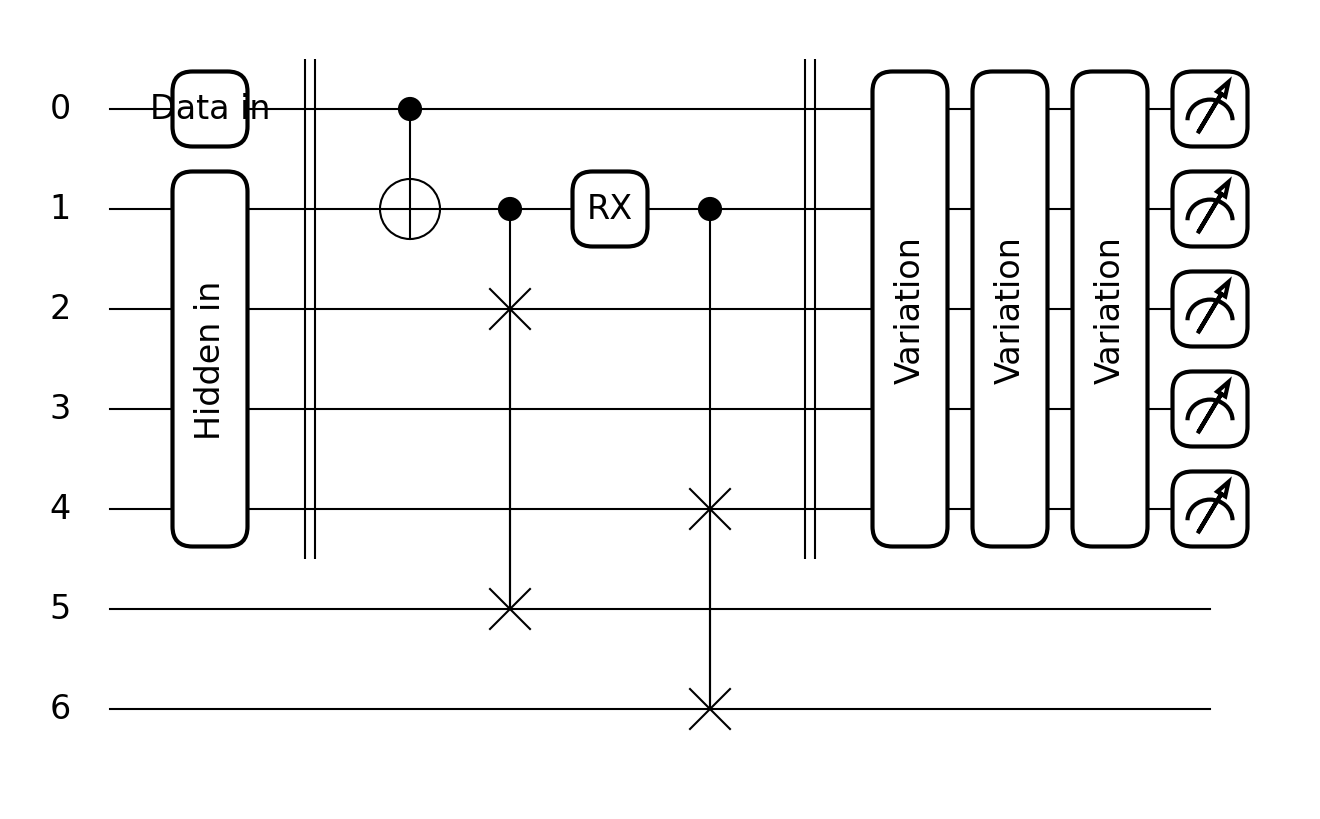

In [10]:
# kk.draw_circuit(level='user')
# kk.draw_circuit(level='device')
kk.draw_circuit()